# Spatial Data Exploration and Preprocessing with IPUMS NHGIS
### by [Kate Vavra-Musser](https://vavramusser.github.io) for the [R Spatial Notebook Series](https://vavramusser.github.io/r-spatial)

## Introduction

This notebook demonstrates the process of cleaning and preparing spatial data for analysis.  The notebook uses data extracted from the [IPUMS National Historical Geographic Information System (NHGIS)](https://www.nhgis.org) repository, which provides harmonized data from the U.S. Decennial Census, American Community Survey, and other sources.  Working with spatial data, like the data included in the IPUMS NHGIS repository, requires specalized management of the complex relationships between geographic boundaries and attribute data, as well as attention to the nuances of georeferenced data. This notebook will guide you through steps in a typical spatial data management process, including importing, joining, and preparing tabular and boundary data to create clean, analysis-ready spatial datasets.

### Notebook Goals
This notebook introduces a typical spatial data management workflow using previously-downloaded [IPUMS NHGIS](https://www.nhgis.org) data using the [IPUMS API](https://developer.ipums.org/docs/v2/apiprogram) via the [ipumsr R package](https://cran.r-project.org/web/packages/ipumsr/index.html).  This notebook is intended as a follow-up to [2.4 IPUMS NHGIS Data Extraction Using ipumsr](https://platform.i-guide.io/notebooks/be08e56e-1c08-458e-a230-263c64d386bc).  By the end of this notebook, users will have the skills to create their own workflows managing spatial NHGIS IPUMS data or other spatial for social and demographic research workflows.

### âœ¨ Prerequisites âœ¨
* Complete [Introduction to IPUMS and the IPUMS API](https://platform.i-guide.io/notebooks/82d3b176-e4e6-4307-8186-318a3fe6c81a)
* Complete [Introduction to sf: Reading, Writing, and Inspecting Vector Data](https://platform.i-guide.io/notebooks/9968babe-22e4-4c3d-98e2-d8b45e9672cd)
* Complete [Working with CRS: Reprojection and Transformation](https://platform.i-guide.io/notebooks/76912ca7-73e4-437e-8ecf-0cb456bd7282)
* Complete [Preparing Vector Data for Analysis](https://platform.i-guide.io/notebooks/44926d85-7f08-4774-a103-a22ff3876cad)
* Complete [IPUMS NHGIS Data Extraction Using ipumsr](https://platform.i-guide.io/notebooks/be08e56e-1c08-458e-a230-263c64d386bc)

### ðŸ’½ Data Used in this Notebook ðŸ’½
* IPUMS NHGIS Example Data Extraction (*ipums_nhgis_example.zip*)
  * If you worked through [IPUMS NHGIS Data Extraction Using ipumsr](https://platform.i-guide.io/datasets/b033e365-cb1f-41d6-ad99-e6a13c41127c) you should have created and saved a copy of *ipums_nhgis_example.zip* in the final section of the notebook.
  * You can also download a copy of *ipums_nhgis_example.zip* file from [the I-GUIDE platform](https://platform.i-guide.io/datasets/0cb99a7c-97c0-4ffc-a2d7-ff539c8eadae) or [Kate's GitHub](https://github.com/vavramusser/r-spatial/blob/main/ipums_nhgis_example.zip).  You will need to unzip *ipums_nhgis_example.zip* and extract *ipums_nhgis_example.shp* file to your workspace.

#### About the Example Data Set
The [*ipums_nhgis_example*](https://github.com/vavramusser/r-spatial/blob/main/ipums_usa_example.csv) shapefile contains total population counts from the 1990, 2000, 2010, and 2020 [U.S. Decennial Censuses](https://www.census.gov/programs-surveys/decennial-census.html) for all counties in the state of California, standardized to 2010 geographic boundaries.  The United States [Decennial Census](https://www.census.gov/programs-surveys/decennial-census.html) is a population and housing count conducted by the [U.S. Census Bureau](https://www.census.gov) every ten years. The Census aims to count every person living in the United States and its territories, collecting basic demographic information such as age, sex, race, ethnicity, and household relationships.  It is designed to provide a comprehensive snapshot of the nation's population and housing characteristics at a specific point in time.

#### Notebook Overview
1. Setup
2. Importing and Exploring Spatial Data
3. Spatial Data Management and Validation

## 1. Setup

This section will guide you through the process of installing essential packages.

[**geojsonio**](https://cran.r-project.org/web/packages/geojsonio/index.html) Â· Convert Data from and to *[GeoJSON](https://geojson.org)* or *[TopoJSON](https://github.com/topojson/topojson)*.

[**ggplot2**](https://cran.r-project.org/web/packages/ggplot2/index.html) Â· Create Elegant Data Visualisations Using the Grammar of Graphics.  A system for 'declaratively' creating graphics, based on "The Grammar of Graphics". You provide the data, tell 'ggplot2' how to map variables to aesthetics, what graphical primitives to use, and it takes care of the details.  This notebook uses the following functions from *ggplot2*.

* [*aes*](https://rdrr.io/cran/ggplot2/man/aes.html) Â· Construct aesthetic mappings
* *CoordSf* Â· Visualize sf objects
  * *geom_sf* Â· geometric objects (points, lines, or polygons)
* [*ggplot*](https://rdrr.io/cran/ggplot2/man/ggplot.html) Â· Create a new ggplot
* [*ggtheme*](https://rdrr.io/cran/ggplot2/man/ggtheme.html) Â· Complete themes
  * *theme_minimal* Â· Minimal theme
* [*labs*](https://rdrr.io/cran/ggplot2/man/labs.html) Â· Modify axis, legend, and plot labels

[**sf**](https://cran.r-project.org/web/packages/sf/index.html) Â· Support for simple features, a standardized way to encode spatial vector data. Binds to 'GDAL' for reading and writing data, to 'GEOS' for geometrical operations, and to 'PROJ' for projection conversions and datum transformations. Uses by default the 's2' package for spherical geometry operations on ellipsoidal (long/lat) coordinates.  This notebook uses the following functions from *sf*.

* [*st_crs*](https://rdrr.io/cran/sf/man/st_crs.html) Â· Retrieve coordinate reference system from object
* [*st_geometry*](https://rdrr.io/cran/sf/man/st_geometry.html) Â· Get, set, replace or rename geometry from an sf object
* [*st_read*](https://rdrr.io/cran/sf/man/st_read.html) Â· Read simple features or layers from file or database
* [*st_write*](https://rdrr.io/cran/sf/man/st_write.html) Â· Write simple features object to file or database
* [*valid*](https://rdrr.io/cran/sf/man/valid.html) Â· Check validity or make an invalid geometry valid
  * *st_make_valid* Â· Make an invalid geometry valid
  * *st_is_valid* Â· Check validity

### 1a. Install and Load Required Packages
If you have not already installed the required packages, uncomment and run the code below:

### 1a. Install and Load Required Packages

If you have not already installed the required packages, uncomment and run the code below:

In [25]:
# install.packages(c("geojsonio", "ggplot2", "sf"))

Load the packages into your workspace.

In [26]:
library(geojsonio)
library(ggplot2)
library(sf)

## 2. Importing and Exploring Spatial Data

First we will read in the *ipums_nhgis_example.shp* shapefile into memory using the [*st_read*](https://rdrr.io/cran/sf/man/st_read.html) function from the [**sf**](https://cran.r-project.org/web/packages/sf/index.html) package.  You may need to update the file path to reflect the file's location on your machine or in your working directory.

The [*st_read*](https://rdrr.io/cran/sf/man/st_read.html) function reads spatial data files (like shapefiles) into an [*sf object*](https://r-spatial.github.io/sf/articles/sf1.html), which includes both attribute and geometry data.  The *sf object* allows you to treat spatial data like a regular data frame while retaining its spatial attributes.

In [27]:
unzip("ipums_nhgis_example.zip")
dat <- st_read("ipums_nhgis_example.shp")

Reading layer `ipums_nhgis_example' from data source 
  `C:\Users\vavra\Dropbox\R Spatial\r-spatial\05 Data Cleaning, Preparation, and Exploratory Data Analysis (EDA)\ipums_nhgis_example.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 58 features and 32 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -2356114 ymin: -364426.6 xmax: -1646660 ymax: 845925.2
Projected CRS: USA_Contiguous_Albers_Equal_Area_Conic


The *ipums_nhgis_example.shp* file was saved as a shapefile, which includes spatial reference informaiton and metadata, and we get a preview of some of this spatial metadata when we read in the file with [*st_read*](https://rdrr.io/cran/sf/man/st_read.html).

* The data includes **58 features** (the counties in the state of California) and has **32 attribute fields**.
* The bounding box is **(-2356114, -364426.6) (-1646660 845925.2)**
* The coordinate reference system (CRS) is the **[USA Contiguous Albers Equal Area Conic](https://en.wikipedia.org/wiki/Albers_projection) projected CRS**

Let's take a look at the first few lines of the data.

As a reminder, the [*ipums_nhgis_example.shp*](https://github.com/vavramusser/r-spatial/blob/main/ipums_usa_example.csv) file contains total population counts from the 1990, 2000, 2010, and 2020 [U.S. Decennial Censuses](https://www.census.gov/programs-surveys/decennial-census.html) for all counties in the state of California.

In [28]:
head(dat)

GISJOIN  GEOGYEAR STATE      STATEA COUNTY           COUNTYA CL8AA1990 
1 G0600010 2010     California 06     Alameda County   001     1279178.40
2 G0600030 2010     California 06     Alpine County    003        1113.00
3 G0600050 2010     California 06     Amador County    005       30039.00
4 G0600070 2010     California 06     Butte County     007      182119.15
5 G0600090 2010     California 06     Calaveras County 009       31998.00
6 G0600110 2010     California 06     Colusa County    011       16274.91
  CL8AA1990L CL8AA1990U CL8AA2000  geometry                       ... CLASSFP10
1 1278359    1279184    1443736.01 MULTIPOLYGON (((-2247215 30... ... H1       
2    1113       1174       1208.00 MULTIPOLYGON (((-2010860 38... ... H1       
3   29956      30039      35100.00 MULTIPOLYGON (((-2051788 39... ... H1       
4  181972     182293     203169.91 MULTIPOLYGON (((-2109286 51... ... H1       
5   31998      31998      40554.00 MULTIPOLYGON (((-2057214 37... ... H1       
6   16248      16313      18803.92 MULTIPOLYGON (((-2252182 53... ... H1       
  MTFCC10 CSAFP10 CBSAFP10 METDIVFP10 FUNCSTAT10 INTPTLAT10  INTPTLON10  
1 G4020   488     41860    36084      A          +37.6480811 -121.9133039
2 G4020   NA      NA       NA         A          +38.6176096 -119.7989986
3 G4020   NA      NA       NA         A          +38.4435501 -120.6538563
4 G4020   NA      17020    NA         A          +39.6659588 -121.6019188
5 G4020   NA      NA       NA         A          +38.1878437 -120.5551154
6 G4020   NA      NA       NA         A          +39.1777385 -122.2375629
  Shape_len geometry                      
1 376006.7  MULTIPOLYGON (((-2247215 30...
2 215455.7  MULTIPOLYGON (((-2010860 38...
3 281171.4  MULTIPOLYGON (((-2051788 39...
4 404374.1  MULTIPOLYGON (((-2109286 51...
5 288191.5  MULTIPOLYGON (((-2057214 37...
6 298275.9  MULTIPOLYGON (((-2252182 53...

In [Chapter 2.4](https://platform.i-guide.io/notebooks/be08e56e-1c08-458e-a230-263c64d386bc) we set up our IPUMS API extraction to return total population data for the 1990, 2000, 2010, and 2020 Decennial Censuses.  However, IPUMS includes a set of preselected variables in data extractions including metadata and other supplemental information whch account for the additional 12 variables.

Let's take a look at the list of column names.

In [29]:
colnames(dat)

[1] "GISJOIN"    "GEOGYEAR"   "STATE"      "STATEA"     "COUNTY"    
 [6] "COUNTYA"    "CL8AA1990"  "CL8AA1990L" "CL8AA1990U" "CL8AA2000" 
[11] "CL8AA2000L" "CL8AA2000U" "CL8AA2010"  "CL8AA2020"  "CL8AA2020L"
[16] "CL8AA2020U" "STATEFP10"  "COUNTYFP10" "COUNTYNS10" "GEOID10"   
[21] "NAME10"     "NAMELSAD10" "LSAD10"     "CLASSFP10"  "MTFCC10"   
[26] "CSAFP10"    "CBSAFP10"   "METDIVFP10" "FUNCSTAT10" "INTPTLAT10"
[31] "INTPTLON10" "Shape_len"  "geometry"

Below is a referece list of the variables included in the data.  This list includes the 4 total population variables and 6 total population lower and upper bound variables for the four Censuses represented in the data as well as IPUMS preselected geographic variables from the time-series table and additional geographic variables included in the original shapefile from our extract.  After we merged the time-series tabular and spatial datasets at the end of [Chapter 2.4](https://platform.i-guide.io/notebooks/be08e56e-1c08-458e-a230-263c64d386bc) the combined dataset includes all variables from both original sources.  Recall that before saving the merged data we removed the Land Area in Square Meters (ALAND10), Water Area in Square Meters (AWATER10), and Shape Area (Shape_area) attributes due to space limitations.

**Population Variables**
* 1990 Total Population Estimate (CL8AA1990)
* 1990 Total Population Lower Bound (CL8AA1990L)
* 1990 Total Population Upper Bound (CL8AA1990U)
* 2000 Total Population Estimate (CL8AA2000)
* 2000 Total Population Lower Bound (CL8AA2000L)
* 2000 Total Population Upper Bound (CL8AA2000U)
* 2010 Total Population (CL8AA2010)
* 2020 Total Population Estimate (CL8AA2020)
* 2020 Total Population Lower Bound (CL8AA2020L)
* 2020 Total Population Upper Bound (CL8AA2020U)

**Geographic Variables (from the Time-Series Tables)**
* Geography Year (GEOGYEAR)
* State Name (STATE)
* State FIPS Code (STATEA)
* County Name (COUNTY)
* County FIPS Code (COUNTYA)

**Geographic Variables (from the original Shapefile)**
* State FIPS Code (STATEFP10)
* County FIPS Code (COUNTYFP10)
* COUNTYNS10
* Geographic Identifier (GEOID10)
* County Name (NAME10)
* Legal/Statistical Area Description (LSAD) Name (NAMELSAD10)
* FIPS Class Code (CLASSFP10)
* Combined Statistical Area (CSA) FIPS Code (CSAFP10)
* Core-Based Statistical Area (CBSA) FIPS Code (CBSAFP10)
* Metropolitan Division FIPS Code (METDIVFP10)
* Functional Status (FUNCSTAT10)
* Internal Point (Centroid) Latitude Coordinate (INTPTLAT10)
* Internal Point (Centroid) Longitude Coordinate (INTPTLON10)
* Shape Length (Shape_len)
* Spatial Geometry (geometry)

**GIS Join**
* GIS Join Match Code (GISJOIN)

### 2a. Exploring the sf Object Data Structure

After importing the data and reviewing the tabular attribute data, weâ€™ll explore its structure and spatial attributes.  First we'll take a look at the structure of the data using the *str* command.

In [30]:
str(dat)

Classes 'sf' and 'data.frame':	58 obs. of  33 variables:
 $ GISJOIN   : chr  "G0600010" "G0600030" "G0600050" "G0600070" ...
 $ GEOGYEAR  : num  2010 2010 2010 2010 2010 2010 2010 2010 2010 2010 ...
 $ STATE     : chr  "California" "California" "California" "California" ...
 $ STATEA    : chr  "06" "06" "06" "06" ...
 $ COUNTY    : chr  "Alameda County" "Alpine County" "Amador County" "Butte County" ...
 $ COUNTYA   : chr  "001" "003" "005" "007" ...
 $ CL8AA1990 : num  1279178 1113 30039 182119 31998 ...
 $ CL8AA1990L: num  1278359 1113 29956 181972 31998 ...
 $ CL8AA1990U: num  1279184 1174 30039 182293 31998 ...
 $ CL8AA2000 : num  1443736 1208 35100 203170 40554 ...
 $ CL8AA2000L: num  1442990 1208 35065 203080 40554 ...
 $ CL8AA2000U: num  1443741 1208 35100 203316 40554 ...
 $ CL8AA2010 : num  1510271 1175 38091 220000 45578 ...
 $ CL8AA2020 : num  1682478 1204 40474 211632 45292 ...
 $ CL8AA2020L: num  1680524 1204 40474 211632 45292 ...
 $ CL8AA2020U: num  1684068 1204 40474 21

This view provides a different snapshot of the data than the typical tabular format.  We can see each of the attributes listed first with information on the data type for each attribute and a preview of some of the first few rows of data.

Below the attribute list we see the *geometry* column.  This special column differentiates an [*sf object*](https://r-spatial.github.io/sf/articles/sf1.html) from a typical *data.frame*.  The *geometry* column contains a multipolygon for each feature in the dataset and each multipolygon is further made up of a series of coordinate corresponding to the points which makde up the polygon shape.

### 2b. Exploring the Coordinate Reference System
Next we will check out the coordinate reference system (CRS) for our data using the [*st_crs*](https://rdrr.io/cran/sf/man/st_crs.html) function from the [**sf**](https://cran.r-project.org/web/packages/sf/index.html) package.

In [31]:
# retuns the CRS
st_crs(dat)

Coordinate Reference System:
  User input: USA_Contiguous_Albers_Equal_Area_Conic 
  wkt:
PROJCRS["USA_Contiguous_Albers_Equal_Area_Conic",
    BASEGEOGCRS["NAD83",
        DATUM["North American Datum 1983",
            ELLIPSOID["GRS 1980",6378137,298.257222101,
                LENGTHUNIT["metre",1]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["Degree",0.0174532925199433]]],
    CONVERSION["USA_Contiguous_Albers_Equal_Area_Conic",
        METHOD["Albers Equal Area",
            ID["EPSG",9822]],
        PARAMETER["Latitude of false origin",37.5,
            ANGLEUNIT["Degree",0.0174532925199433],
            ID["EPSG",8821]],
        PARAMETER["Longitude of false origin",-96,
            ANGLEUNIT["Degree",0.0174532925199433],
            ID["EPSG",8822]],
        PARAMETER["Latitude of 1st standard parallel",29.5,
            ANGLEUNIT["Degree",0.0174532925199433],
            ID["EPSG",8823]],
        PARAMETER["Latitude of 2nd standard parallel",45.5,
            ANGLEUNI

This view provides us with a lot of metainformation about our data's CRS, the [USA Contiguous Albers Equal Area Conic](https://en.wikipedia.org/wiki/Albers_projection) projection, including:

* [datum](https://en.wikipedia.org/wiki/Geodetic_datum): **[North American Datum 1983 (NAD83)](https://en.wikipedia.org/wiki/North_American_Datum)**
* [ellipsoid](https://en.wikipedia.org/wiki/Earth_ellipsoid): **[Geodetic Reference System 1980](https://en.wikipedia.org/wiki/Geodetic_Reference_System_1980)**
* [(EPSG) code](https://en.wikipedia.org/wiki/EPSG_Geodetic_Parameter_Dataset): **[9822](https://epsg.io/9822-method)** or **[ESRI 102003](https://epsg.io/102003)**
* units: meters

We can also set the [*st_crs*](https://rdrr.io/cran/sf/man/st_crs.html) parameter *parameters* to *TRUE* to get a list of detailed CRS parameters.

In [32]:
# returns the list of CRS parameters
st_crs(dat, parameters = T)

$SemiMajor
6378137 [m]

$SemiMinor
6356752 [m]

$InvFlattening
[1] 298.2572

$IsGeographic
[1] FALSE

$units_gdal
[1] "metre"

$IsVertical
[1] FALSE

$WktPretty
[1] "PROJCS[\"USA_Contiguous_Albers_Equal_Area_Conic\",\n    GEOGCS[\"NAD83\",\n        DATUM[\"North_American_Datum_1983\",\n            SPHEROID[\"GRS 1980\",6378137,298.257222101]],\n        PRIMEM[\"Greenwich\",0],\n        UNIT[\"Degree\",0.0174532925199433]],\n    PROJECTION[\"Albers_Conic_Equal_Area\"],\n    PARAMETER[\"latitude_of_center\",37.5],\n    PARAMETER[\"longitude_of_center\",-96],\n    PARAMETER[\"standard_parallel_1\",29.5],\n    PARAMETER[\"standard_parallel_2\",45.5],\n    PARAMETER[\"false_easting\",0],\n    PARAMETER[\"false_northing\",0],\n    UNIT[\"metre\",1],\n    AXIS[\"Easting\",EAST],\n    AXIS[\"Northing\",NORTH],\n    AUTHORITY[\"ESRI\",\"102003\"]]"

$Wkt
[1] "PROJCS[\"USA_Contiguous_Albers_Equal_Area_Conic\",GEOGCS[\"NAD83\",DATUM[\"North_American_Datum_1983\",SPHEROID[\"GRS 1980\",6378137,298.

Using this we can also programmitally call individual components of the CRS parameter list.

In [33]:
# returns the name CRS name
st_crs(dat, parameters = T)$Name

# returns the proj4string
st_crs(dat, parameters = T)$proj4string

[1] "USA_Contiguous_Albers_Equal_Area_Conic"

[1] "+proj=aea +lat_0=37.5 +lon_0=-96 +lat_1=29.5 +lat_2=45.5 +x_0=0 +y_0=0 +datum=NAD83 +units=m +no_defs"

### 2c. Mapping Raw Geometry

Although our data includes multiple attributes, including the Census total population data we are interested in, it isuseful to take a look at the raw geometry prior to further analysis.  We can access the raw geometry of our file using the [*st_geometry*](https://rdrr.io/cran/sf/man/st_geometry.html) function from the [**sf**](https://cran.r-project.org/web/packages/sf/index.html) package and plot it with the basic *plot* function.

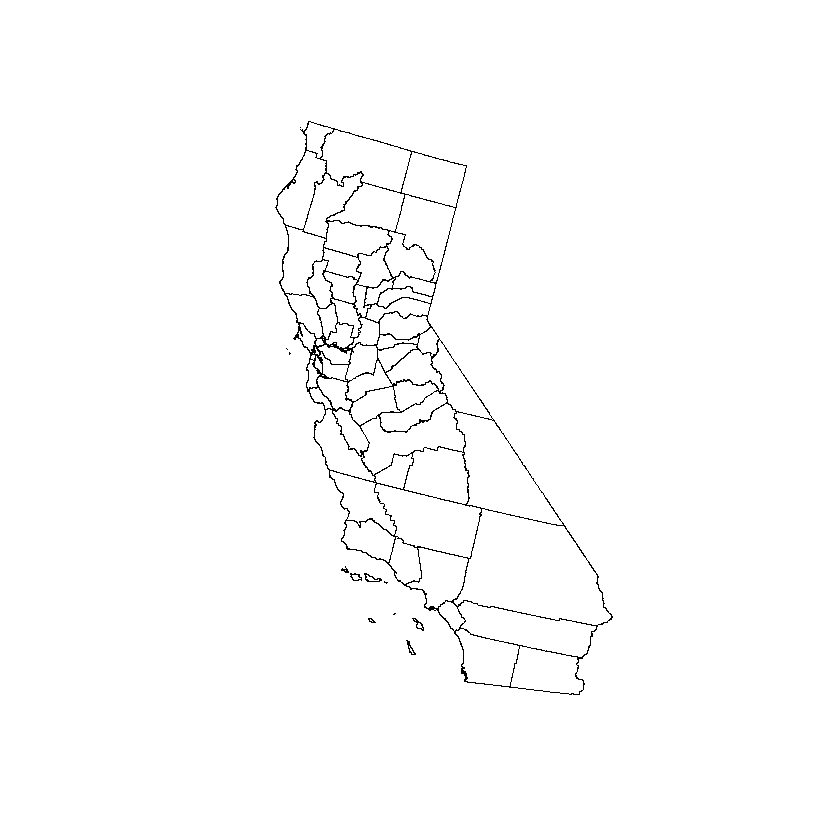

In [34]:
# plots the raw geometry without attributes
plot(st_geometry(dat))

### 2d. Mapping Raw Geometry with ggplot2

In addition to the simple map made with the base R *plot* function, we can also make more complicated maps with the [**ggplot2**](https://cran.r-project.org/web/packages/ggplot2/index.html) package.  We will use *ggplots* to create more elaborate maps in later notebooks, but for now we will create a simple map of the raw geometry for our data.

The code below sets up a *ggplot* and specifies style parameters.

* [*ggplot*](https://rdrr.io/cran/ggplot2/man/ggplot.html) sets up the *ggplot* plot object and specifies that we will use *dat* as the data for the plot
* [*geom_sf*](https://ggplot2.tidyverse.org/reference/ggsf.html) adds a layer to plot spatial features from an sf object
* [*labs*](https://rdrr.io/cran/ggplot2/man/labs.html) allows us to add customization including a map title and caption for this map
* [*theme_minimal*](https://rdrr.io/cran/ggplot2/man/ggtheme.html) provides a clean, minimalist theming for the overall map

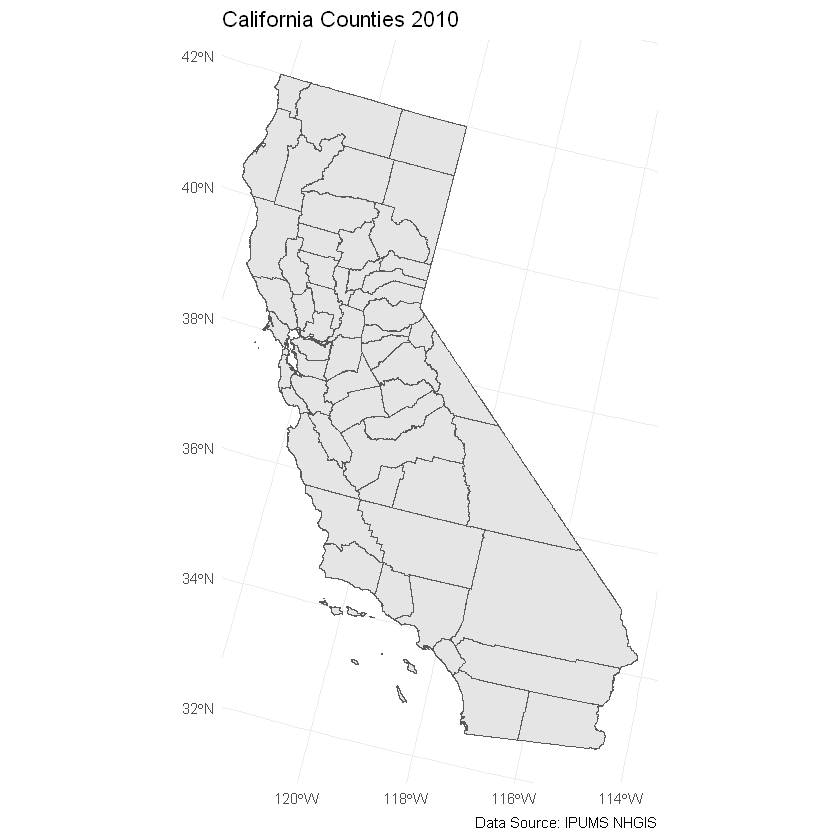

In [35]:
ggplot(data = dat) +
  geom_sf() +
  labs(title = "California Counties 2010",
       caption = "Data Source: IPUMS NHGIS") +
  theme_minimal()

### 2e. Mapping Attribute Data with ggplot2

We can build on the *ggplot* we previously created to map the raw geometries and make a version that maps the 2010 total population attribute (CL8AA2010).  This version of the *ggplot* specifies the attribute to use by specifying the attribute with the [*aes*](https://rdrr.io/cran/ggplot2/man/aes.html) function as a parameter to the *geom_sf* parameter.  The *ggplot* map will automatically use a continuous blue color scheme to visualize the geometries based on the specified attribute value.

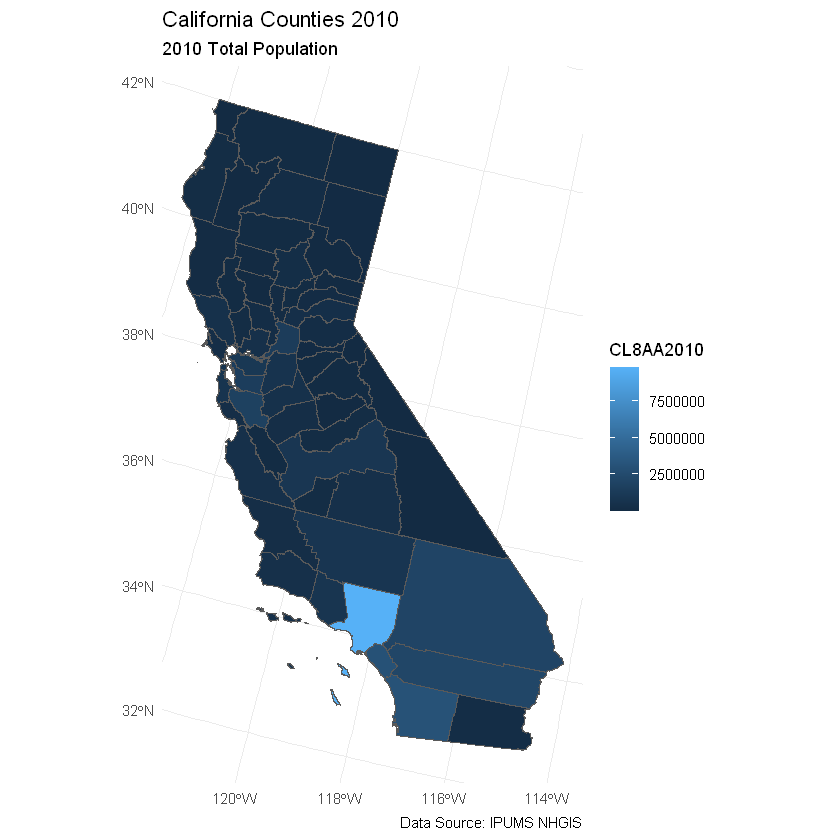

In [36]:
ggplot(data = dat) +
  geom_sf(aes(fill = CL8AA2010)) +
  labs(title = "California Counties 2010",
       subtitle = "2010 Total Population",
       caption = "Data Source: IPUMS NHGIS") +
  theme_minimal()

We can change the color scheme by adding an additional parameter to the *ggplot* object such as the built-in [*scale_colour_continuous*](https://rdrr.io/cran/ggplot2/man/scale_colour_continuous.html) color schemes such as *scale_fill_viridis_c*.

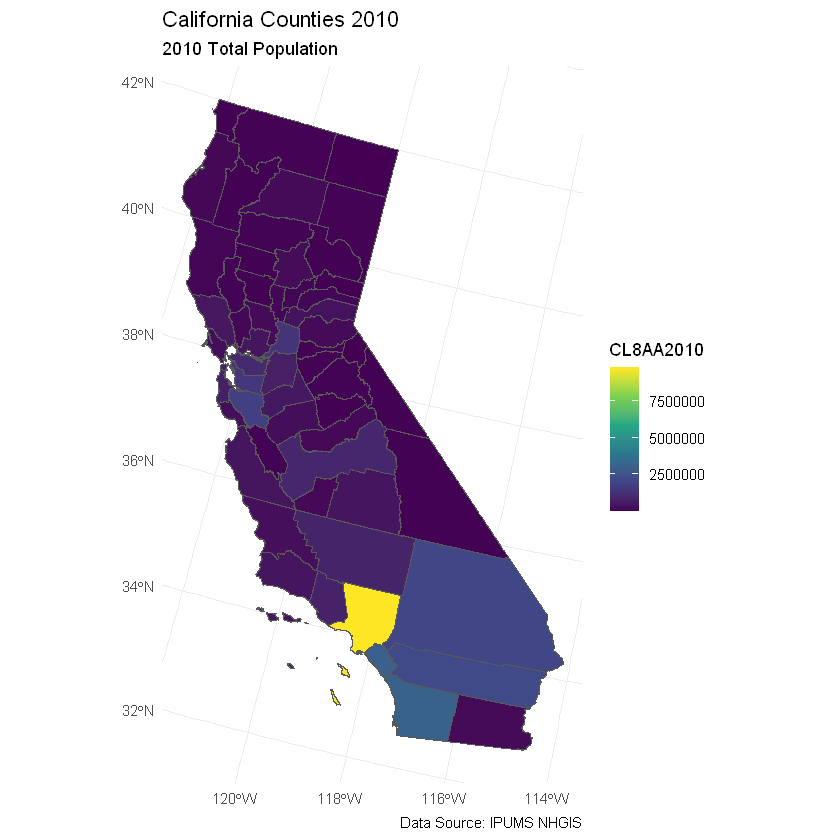

In [37]:
ggplot(data = dat) +
  geom_sf(aes(fill = CL8AA2010)) +
  labs(title = "California Counties 2010",
       subtitle = "2010 Total Population",
       caption = "Data Source: IPUMS NHGIS") +
  theme_minimal() +
  scale_fill_viridis_c()

## 3. Spatial Data Preprocessing

Prior to carrying out spatial data analysis there are a few essential spatial data preprocessing tasks which we should carry out to ensure the integretity of our data and its compatibility for any downstream analysis.

### 3a. Reprojecting Data

In addition to viewing our data's CRS, we can also reproject data using the [*st_transform*](https://rdrr.io/cran/sf/man/st_transform.html) function from the [**sf**](https://cran.r-project.org/web/packages/sf/index.html) package.  This can help ensure compatibility between layers or to use a CRS suitable for your analysis.

We can reproject to a different CRS using the appropriate [(EPSG) code](https://en.wikipedia.org/wiki/EPSG_Geodetic_Parameter_Dataset) for our desired CRS.

In [38]:
# reproject to WGS84 (EPSG:4326)
dat_reproj <- st_transform(dat, crs = 4326)

If we plot the new version of the data, we can see that the data has been reprojected.

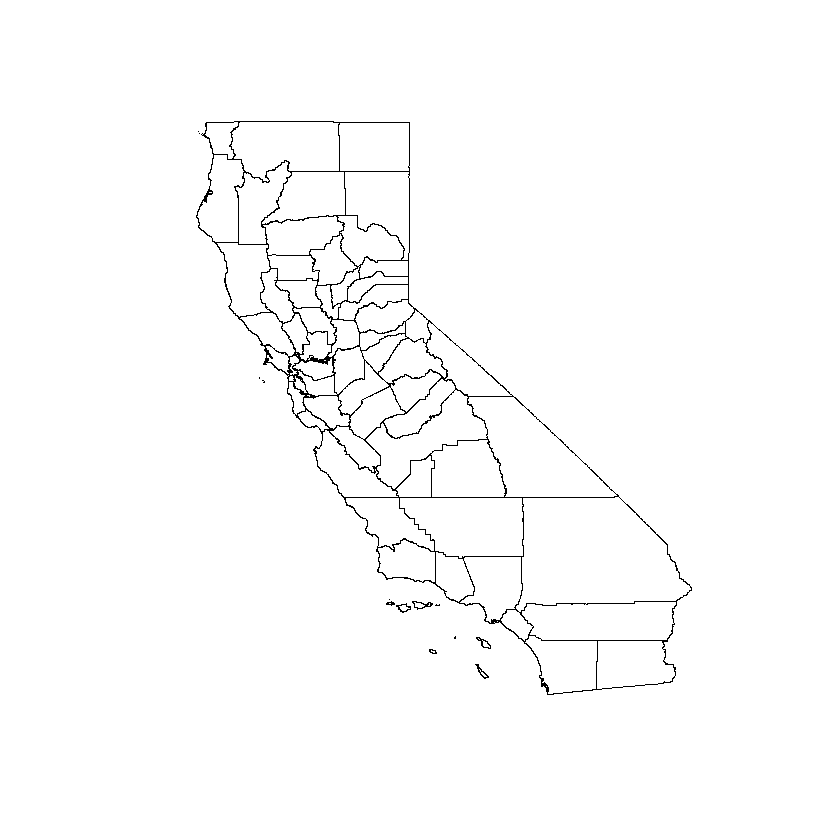

In [39]:
plot(st_geometry(dat_reproj))

You can also use the [*st_transform*](https://rdrr.io/cran/sf/man/st_transform.html) function to easily reproject a file to match the projection of another file by passing the file's CRS using [*st_crs*](https://rdrr.io/cran/sf/man/st_crs.html).  This is especially useful if you are bringing in multiple data sources to your project and need to ensure they are all projected in the same CRS.

In the example below we project the *dat_reproj* object back to the CRS of the *dat* object.

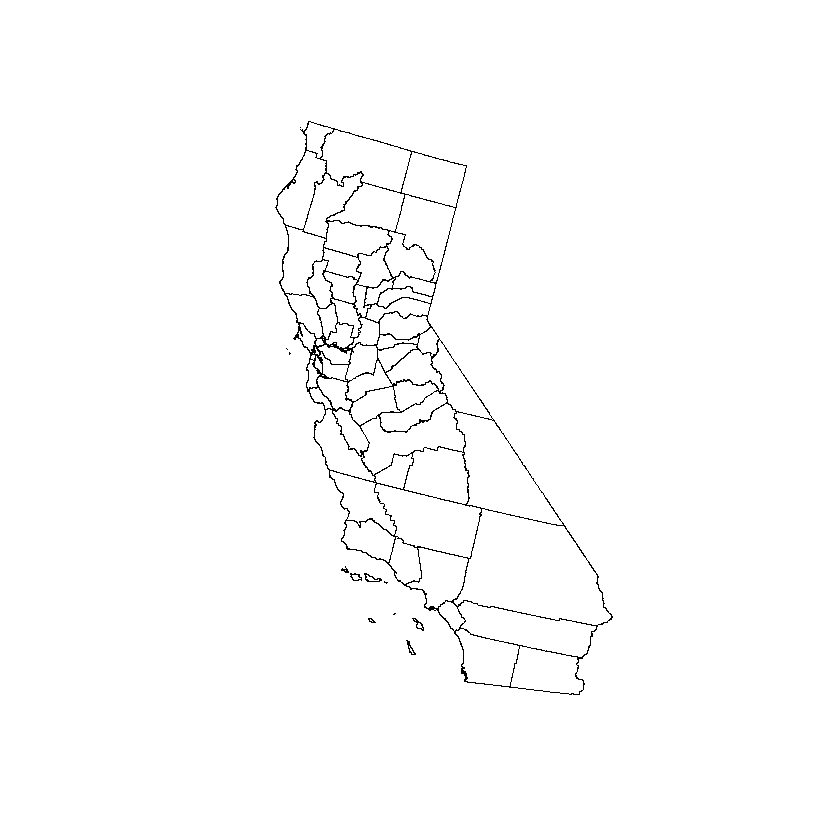

In [40]:
# reproject dat_reproj back to the dat CRS (9822)
dat_reproj <- st_transform(dat_reproj, st_crs(dat))

plot(st_geometry(dat_reproj))

*plot_reproj* is now back to the original CRS of *dat*.

**â˜… Pro Tip:**  Here are a few common CRSs and their EPSG codes:

* WGS84 (World Geodetic System 1984) (EPSG:4326): great for global datasets, webmapping, and GPS systems
* WGS84 Pseudo-Mercator (EPSG: 3857): great for web mapping applications
* NAD83 (North American Datum 1983) (EPSG: 4269): great for National datasets covering the entire United States
* NAD83 Albers Equal Area (EPSG:5070): great for National datasets covering the entire United States
* NAD83 Contiguious USA Lambert Conformal Conic (EPSG: 102003): great for National datasets covering the contiguious United States (CONUS) 
* NAD83 UTM (Universal Transverse Mercator) (UTM zone-specific EPSGs): great for analyses in specific UTM zones
* State Plane Coordinate System (SPCS) (region-specific EPSGs): great for analysis at the state and county level

### 3b. Validating Spatial Data

Before proceeding to any spatial analysis or significant spatial data manipulation, we should check to make sure that all the geometries in our dataset are valid.  An invalid geometry in spatial data refers to a geometry that does not conform to the rules of its geometry type or is otherwise problematic for spatial operations. These issues can prevent spatial functions like intersections, unions, or buffering from working correctly.  Invalid geometries can cause errors in spatial operations or produce incorrect map visualizations.

We can use the [*st_is_valid*](https://rdrr.io/cran/sf/man/valid.html) function from the [**sf**](https://cran.r-project.org/web/packages/sf/index.html) package to check for invalid geometries in our data.  The following code stores the output of the *st_is_valid* function, a list of *TRUE* and *FALSE* values indicating the validity of each geometry in the data, stores the list to the *invalid_geometries* object, and counts the number of invalid geometries.

In [41]:
# check for invalid geometries
invalid_geometries <- st_is_valid(dat)

# count invalid geometries
sum(!invalid_geometries)

[1] 1

Our data has one invalid geometry!  Fortunatly we can easily fix it using the [*st_make_valid*](https://rdrr.io/cran/sf/man/valid.html) function from the [**sf**](https://cran.r-project.org/web/packages/sf/index.html) package.

In [42]:
# fix invalid geometries
dat <- st_make_valid(dat)

# check for invalid geometries
sum(!st_is_valid(dat))

[1] 0

Testing the file again using *st_is_valid* now returns 0 invalid geometries.  Our data is now validated and ready for analysis.

### 3c. Save the Data

After the processing steps we should save our data again so we can import it to our next notebook.  We will again save the data as a **shapefile** (*.shp*) using the [*st_write*](https://rdrr.io/cran/sf/man/st_write.html) function from the [**sf**](https://cran.r-project.org/web/packages/sf/index.html) package.

In [43]:
st_write(dat, "ipums_nhgis_analysis.shp", driver = "ESRI Shapefile", delete_dsn = T)

Warning message in CPL_write_ogr(obj, dsn, layer, driver, as.character(dataset_options), :
"GDAL Error 1: ipums_nhgis_analysis.shp does not appear to be a file or directory."


Deleting source `ipums_nhgis_analysis.shp' failed
Writing layer `ipums_nhgis_analysis' to data source 
  `ipums_nhgis_analysis.shp' using driver `ESRI Shapefile'
Writing 58 features with 32 fields and geometry type Multi Polygon.


At the end of this exercise we have a tested and validated version of our IPUMS NHGIS data saved in our workspace.

---

## Quick Code
A clean and simple version of the code included in this notebook.